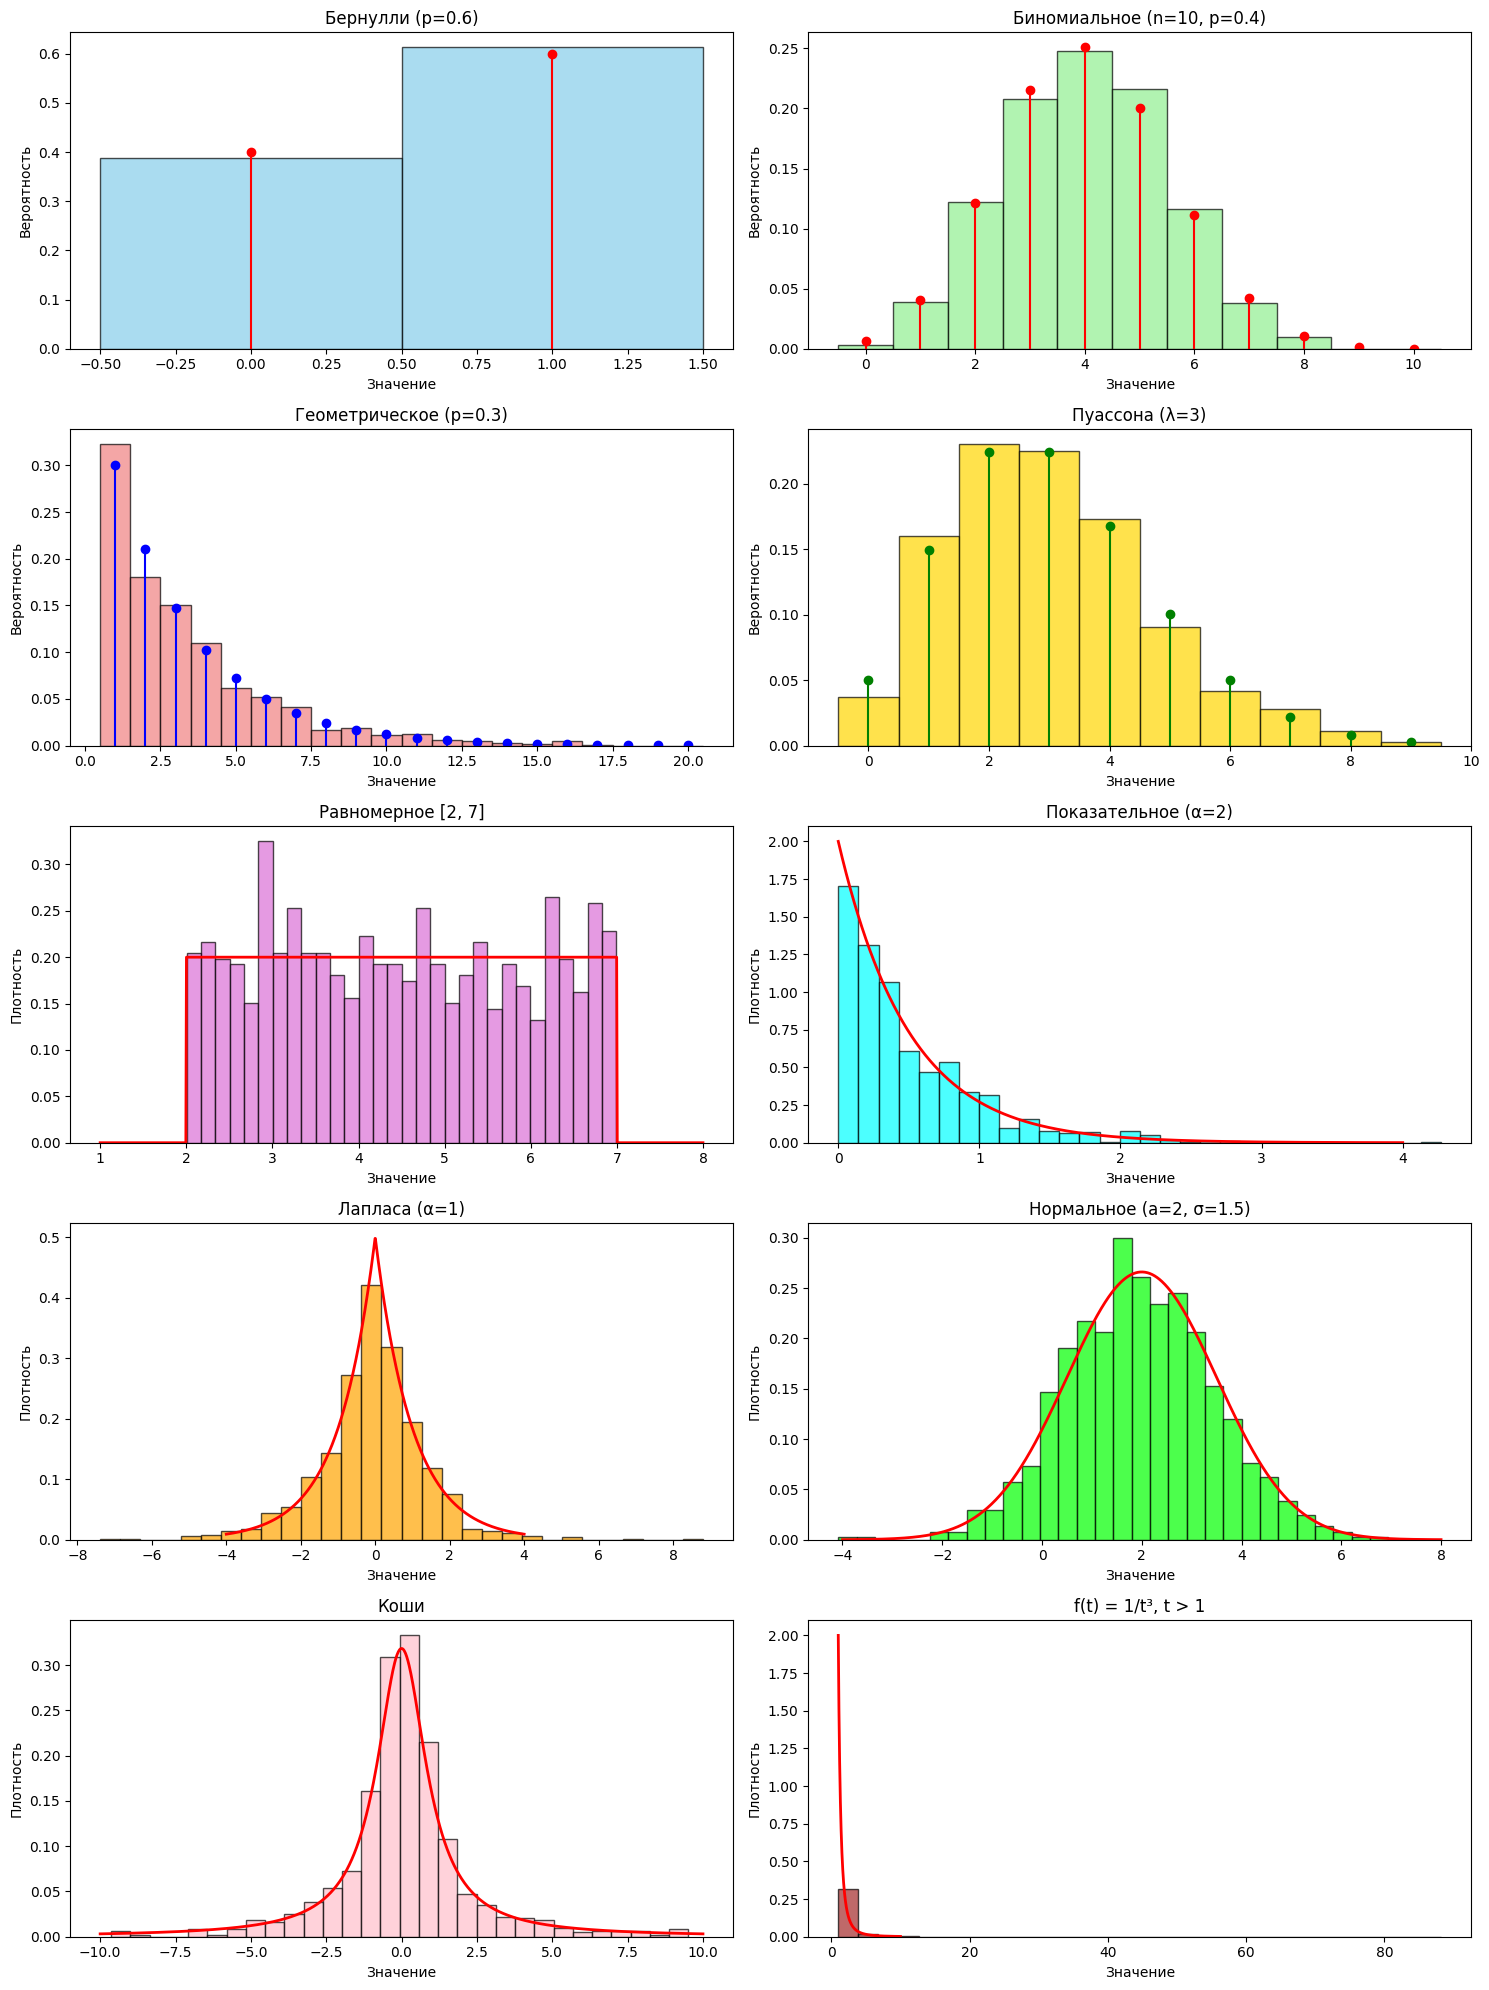

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from math import exp, log, sqrt


# 1. Бернулли с параметром p
def bernoulli(p, size=1):
    """
    Генерация случайных величин с распределением Бернулли
    """
    u = np.random.uniform(0, 1, size)
    return (u <= p).astype(int)


# 2. Биномиальное с параметрами n, p
def binomial(n, p, size=1):
    """
    Генерация случайных величин с биномиальным распределением
    как сумма n независимых испытаний Бернулли
    """
    if size == 1:
        return np.sum(bernoulli(p, n))
    else:
        return np.array([np.sum(bernoulli(p, n)) for _ in range(size)])


# 3. Геометрическое с параметром p
def geometric(p, size=1):
    """
    Генерация случайных величин с геометрическим распределением
    """
    u = np.random.uniform(0, 1, size)
    return np.floor(np.log(u) / np.log(1 - p)).astype(int) + 1


# 4. Пуассона с параметром λ
def poisson(lambd, size=1):
    """
    Генерация случайных величин с распределением Пуассона
    используя метод обратного преобразования
    """

    def single_poisson():
        u = np.random.uniform()
        k = 0
        p = exp(-lambd)
        F = p
        while u > F:
            k += 1
            p *= lambd / k
            F += p
        return k

    if size == 1:
        return single_poisson()
    else:
        return np.array([single_poisson() for _ in range(size)])


# 5. Равномерное на отрезке [a; b]
def uniform(a, b, size=1):
    """
    Генерация случайных величин с равномерным распределением на [a, b]
    """
    u = np.random.uniform(0, 1, size)
    return a + (b - a) * u


# 6. Показательное с параметром α
def exponential(alpha, size=1):
    """
    Генерация случайных величин с показательным распределением
    """
    u = np.random.uniform(0, 1, size)
    return -np.log(1 - u) / alpha


# 7. Лапласа с параметром α
def laplace(alpha, size=1):
    """
    Генерация случайных величин с распределением Лапласа
    """
    u = np.random.uniform(0, 1, size)
    return np.where(u < 0.5, np.log(2 * u) / alpha, -np.log(2 * (1 - u)) / alpha)


# 8. Нормальное с параметрами a и σ² (Бокс-Мюллер)
def normal(a, sigma, size=1):
    """
    Генерация случайных величин с нормальным распределением N(a, σ²)
    """
    if size == 1:
        u1, u2 = np.random.uniform(0, 1, 2)
        z0 = sqrt(-2 * log(u1)) * np.cos(2 * np.pi * u2)
        return a + sigma * z0
    else:
        result = []
        for _ in range((size + 1) // 2):
            u1, u2 = np.random.uniform(0, 1, 2)
            z0 = sqrt(-2 * log(u1)) * np.cos(2 * np.pi * u2)
            z1 = sqrt(-2 * log(u1)) * np.sin(2 * np.pi * u2)
            result.extend([a + sigma * z0, a + sigma * z1])
        return np.array(result[:size])


# 9. Распределение Коши
def cauchy(size=1):
    """
    Генерация случайных величин со стандартным распределением Коши
    """
    u = np.random.uniform(0, 1, size)
    return np.tan(np.pi * (u - 0.5))


# 10. Распределение с ядром f(t) = 1/t³ I{t>1}
def custom_distribution(size=1):
    """
    Генерация случайных величин с плотностью f(t) = 1/t³ для t > 1
    """
    u = np.random.uniform(0, 1, size)
    return 1 / np.sqrt(1 - u)


# Функция для построения графиков
def plot_distributions():
    np.random.seed(42)  # для воспроизводимости
    fig, axes = plt.subplots(5, 2, figsize=(15, 20))
    axes = axes.flatten()

    # 1. Бернулли
    p_bern = 0.6
    sample_bern = bernoulli(p_bern, 1000)
    axes[0].hist(
        sample_bern,
        bins=[-0.5, 0.5, 1.5],
        density=True,
        alpha=0.7,
        color="skyblue",
        edgecolor="black",
    )
    x_bern = [0, 1]
    pmf_bern = [(1 - p_bern), p_bern]
    axes[0].stem(x_bern, pmf_bern, linefmt="r-", markerfmt="ro", basefmt=" ")
    axes[0].set_title(f"Бернулли (p={p_bern})")
    axes[0].set_xlabel("Значение")
    axes[0].set_ylabel("Вероятность")

    # 2. Биномиальное
    n_binom, p_binom = 10, 0.4
    sample_binom = binomial(n_binom, p_binom, 1000)
    bins_binom = np.arange(-0.5, n_binom + 1.5, 1)
    axes[1].hist(
        sample_binom,
        bins=bins_binom,
        density=True,
        alpha=0.7,
        color="lightgreen",
        edgecolor="black",
    )
    x_binom = np.arange(0, n_binom + 1)
    pmf_binom = stats.binom.pmf(x_binom, n_binom, p_binom)
    axes[1].stem(x_binom, pmf_binom, linefmt="r-", markerfmt="ro", basefmt=" ")
    axes[1].set_title(f"Биномиальное (n={n_binom}, p={p_binom})")
    axes[1].set_xlabel("Значение")
    axes[1].set_ylabel("Вероятность")

    # 3. Геометрическое
    p_geom = 0.3
    sample_geom = geometric(p_geom, 1000)
    max_geom = min(20, np.max(sample_geom))
    bins_geom = np.arange(0.5, max_geom + 1.5, 1)
    axes[2].hist(
        sample_geom,
        bins=bins_geom,
        density=True,
        alpha=0.7,
        color="lightcoral",
        edgecolor="black",
    )
    x_geom = np.arange(1, max_geom + 1)
    pmf_geom = p_geom * (1 - p_geom) ** (x_geom - 1)
    axes[2].stem(x_geom, pmf_geom, linefmt="b-", markerfmt="bo", basefmt=" ")
    axes[2].set_title(f"Геометрическое (p={p_geom})")
    axes[2].set_xlabel("Значение")
    axes[2].set_ylabel("Вероятность")

    # 4. Пуассона
    lambda_poiss = 3
    sample_poiss = poisson(lambda_poiss, 1000)
    max_poiss = min(15, np.max(sample_poiss))
    bins_poiss = np.arange(-0.5, max_poiss + 1.5, 1)
    axes[3].hist(
        sample_poiss,
        bins=bins_poiss,
        density=True,
        alpha=0.7,
        color="gold",
        edgecolor="black",
    )
    x_poiss = np.arange(0, max_poiss + 1)
    pmf_poiss = stats.poisson.pmf(x_poiss, lambda_poiss)
    axes[3].stem(x_poiss, pmf_poiss, linefmt="g-", markerfmt="go", basefmt=" ")
    axes[3].set_title(f"Пуассона (λ={lambda_poiss})")
    axes[3].set_xlabel("Значение")
    axes[3].set_ylabel("Вероятность")

    # 5. Равномерное
    a_unif, b_unif = 2, 7
    sample_unif = uniform(a_unif, b_unif, 1000)
    axes[4].hist(
        sample_unif, bins=30, density=True, alpha=0.7, color="orchid", edgecolor="black"
    )
    x_unif = np.linspace(a_unif - 1, b_unif + 1, 1000)
    pdf_unif = np.where(
        (x_unif >= a_unif) & (x_unif <= b_unif), 1 / (b_unif - a_unif), 0
    )
    axes[4].plot(x_unif, pdf_unif, "r-", linewidth=2)
    axes[4].set_title(f"Равномерное [{a_unif}, {b_unif}]")
    axes[4].set_xlabel("Значение")
    axes[4].set_ylabel("Плотность")

    # 6. Показательное
    alpha_exp = 2
    sample_exp = exponential(alpha_exp, 1000)
    axes[5].hist(
        sample_exp, bins=30, density=True, alpha=0.7, color="cyan", edgecolor="black"
    )
    x_exp = np.linspace(0, 4, 1000)
    pdf_exp = alpha_exp * np.exp(-alpha_exp * x_exp)
    axes[5].plot(x_exp, pdf_exp, "r-", linewidth=2)
    axes[5].set_title(f"Показательное (α={alpha_exp})")
    axes[5].set_xlabel("Значение")
    axes[5].set_ylabel("Плотность")

    # 7. Лапласа
    alpha_laplace = 1
    sample_laplace = laplace(alpha_laplace, 1000)
    axes[6].hist(
        sample_laplace,
        bins=30,
        density=True,
        alpha=0.7,
        color="orange",
        edgecolor="black",
    )
    x_laplace = np.linspace(-4, 4, 1000)
    pdf_laplace = 0.5 * alpha_laplace * np.exp(-alpha_laplace * np.abs(x_laplace))
    axes[6].plot(x_laplace, pdf_laplace, "r-", linewidth=2)
    axes[6].set_title(f"Лапласа (α={alpha_laplace})")
    axes[6].set_xlabel("Значение")
    axes[6].set_ylabel("Плотность")

    # 8. Нормальное
    a_norm, sigma_norm = 2, 1.5
    sample_norm = normal(a_norm, sigma_norm, 1000)
    axes[7].hist(
        sample_norm, bins=30, density=True, alpha=0.7, color="lime", edgecolor="black"
    )
    x_norm = np.linspace(a_norm - 4 * sigma_norm, a_norm + 4 * sigma_norm, 1000)
    pdf_norm = stats.norm.pdf(x_norm, a_norm, sigma_norm)
    axes[7].plot(x_norm, pdf_norm, "r-", linewidth=2)
    axes[7].set_title(f"Нормальное (a={a_norm}, σ={sigma_norm})")
    axes[7].set_xlabel("Значение")
    axes[7].set_ylabel("Плотность")

    # 9. Коши
    sample_cauchy = cauchy(1000)
    # Ограничим диапазон для лучшей визуализации
    sample_cauchy_trimmed = sample_cauchy[(sample_cauchy > -10) & (sample_cauchy < 10)]
    axes[8].hist(
        sample_cauchy_trimmed,
        bins=30,
        density=True,
        alpha=0.7,
        color="pink",
        edgecolor="black",
    )
    x_cauchy = np.linspace(-10, 10, 1000)
    pdf_cauchy = 1 / (np.pi * (1 + x_cauchy**2))
    axes[8].plot(x_cauchy, pdf_cauchy, "r-", linewidth=2)
    axes[8].set_title("Коши")
    axes[8].set_xlabel("Значение")
    axes[8].set_ylabel("Плотность")

    # 10. Пользовательское распределение
    sample_custom = custom_distribution(1000)
    axes[9].hist(
        sample_custom,
        bins=30,
        density=True,
        alpha=0.7,
        color="brown",
        edgecolor="black",
    )
    x_custom = np.linspace(1, 10, 1000)
    pdf_custom = 2 / (x_custom**3)  # нормировочная константа = 1/2, поэтому f(t) = 2/t³
    axes[9].plot(x_custom, pdf_custom, "r-", linewidth=2)
    axes[9].set_title("f(t) = 1/t³, t > 1")
    axes[9].set_xlabel("Значение")
    axes[9].set_ylabel("Плотность")

    plt.tight_layout()
    plt.show()


# Демонстрация работы
plot_distributions()

Демонстрация дискретных распределений:


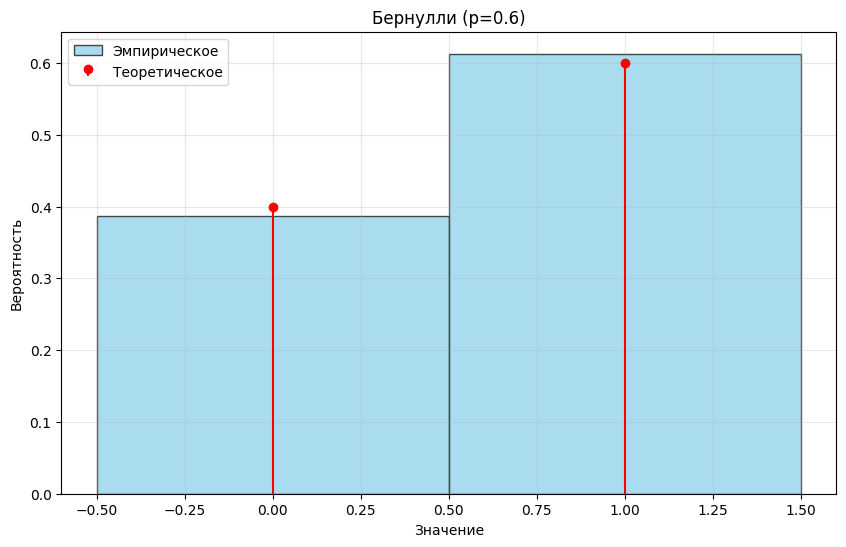

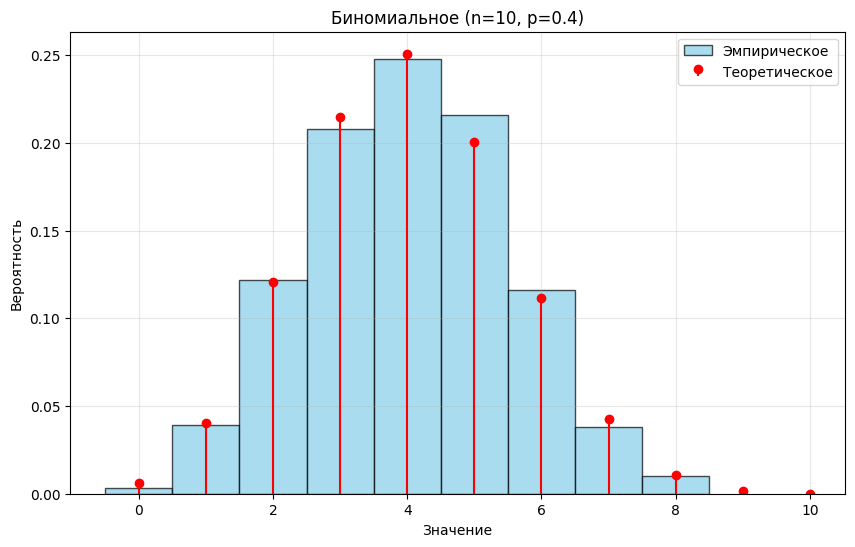

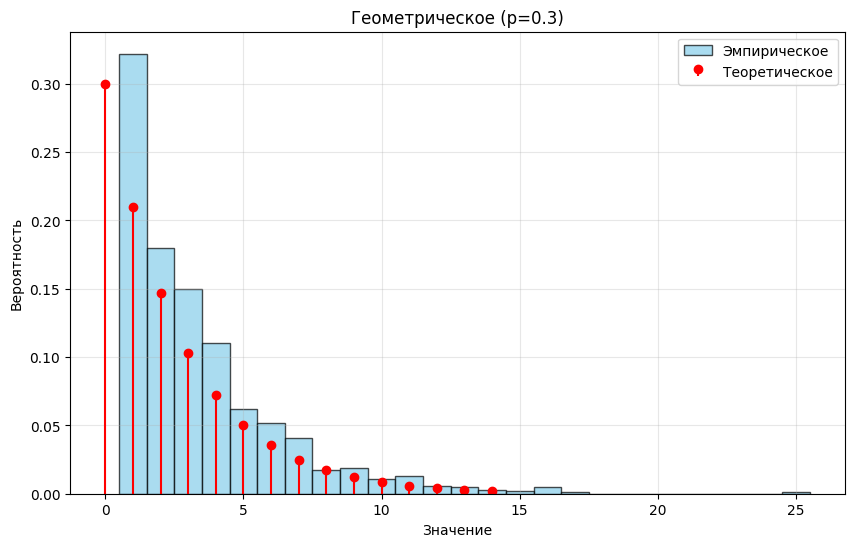

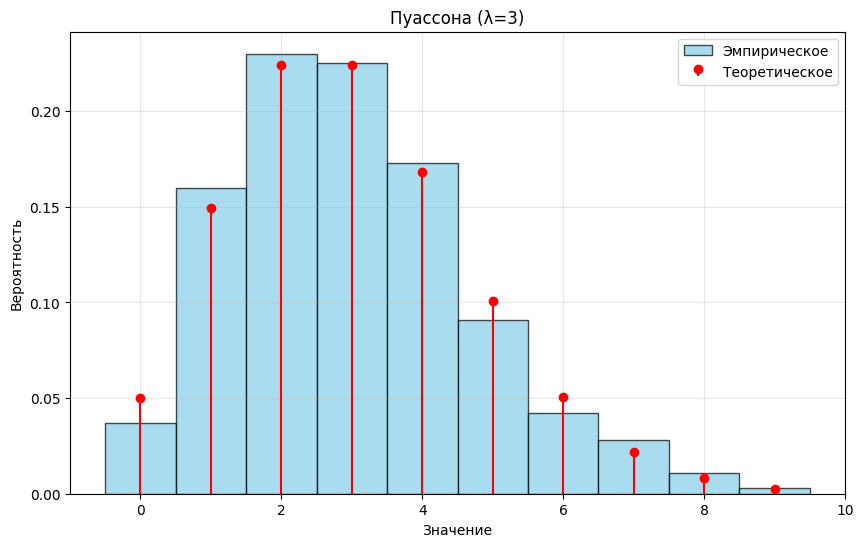


Демонстрация непрерывных распределений:


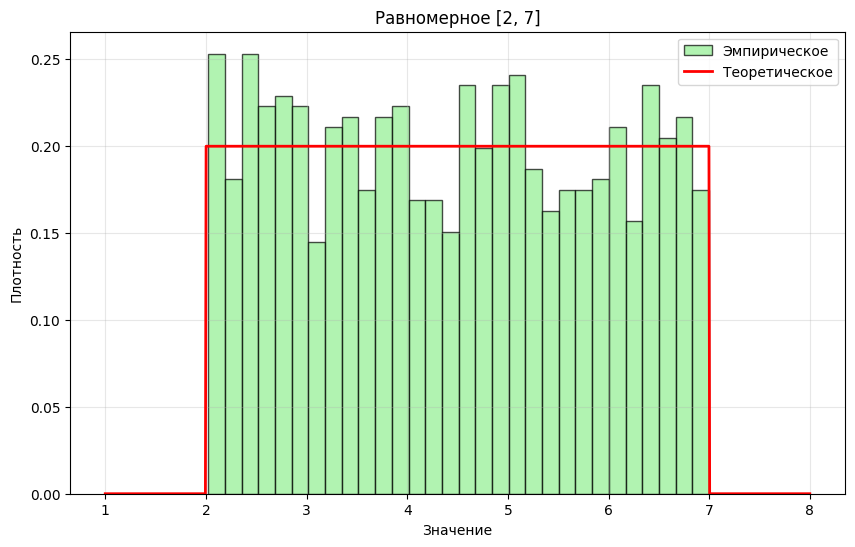

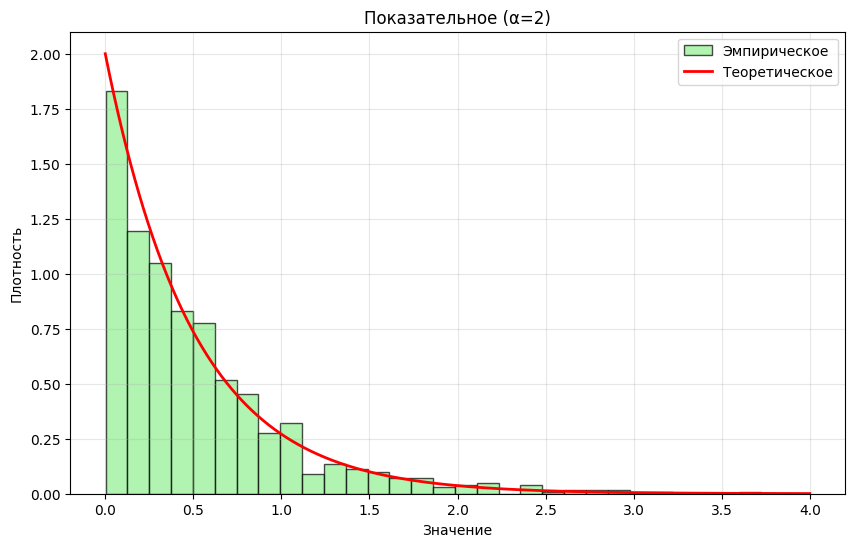

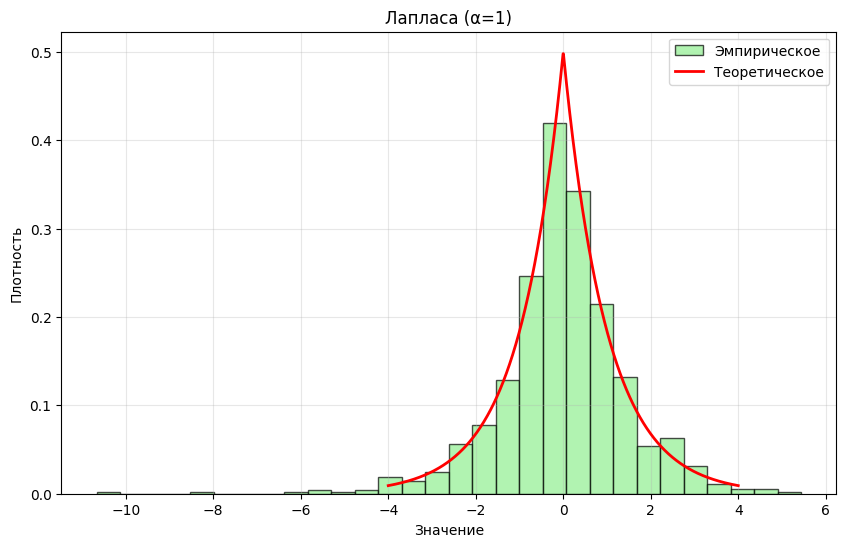

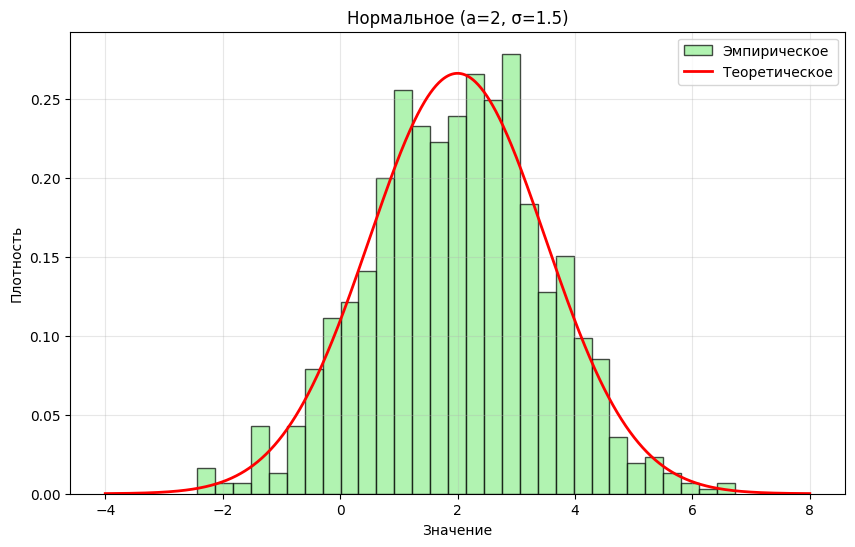

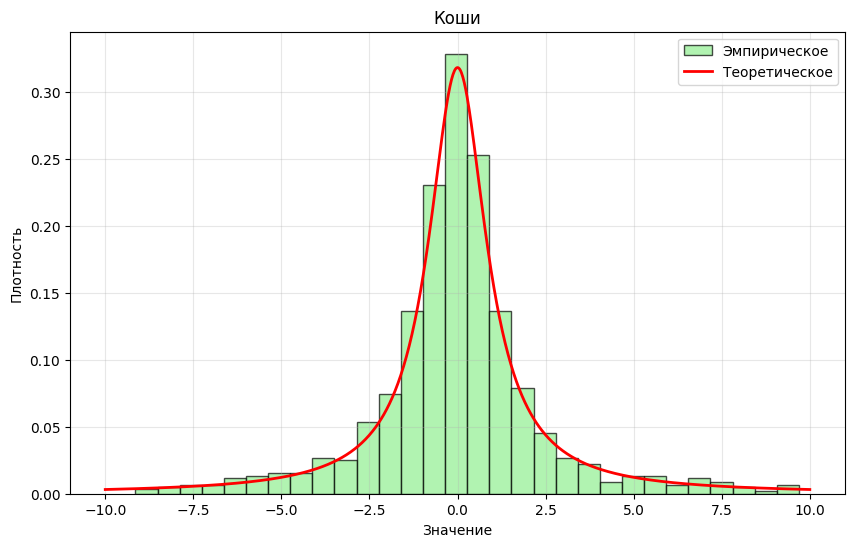

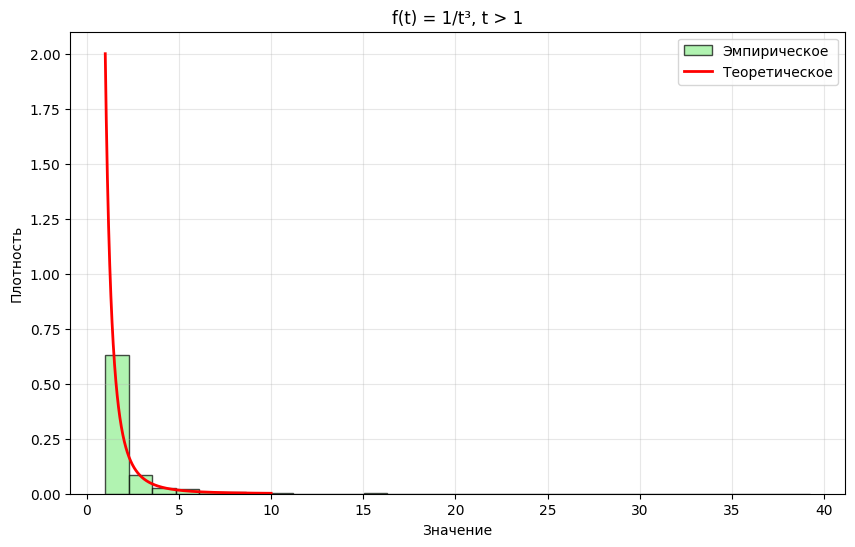

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from math import exp, log, sqrt

# ==================== ФУНКЦИИ ГЕНЕРАЦИИ СЛУЧАЙНЫХ ВЕЛИЧИН ====================


def bernoulli(p, size=1):
    u = np.random.uniform(0, 1, size)
    return (u <= p).astype(int)


def binomial(n, p, size=1):
    if size == 1:
        return np.sum(bernoulli(p, n))
    else:
        return np.array([np.sum(bernoulli(p, n)) for _ in range(size)])


def geometric(p, size=1):
    u = np.random.uniform(0, 1, size)
    return np.floor(np.log(u) / np.log(1 - p)).astype(int) + 1


def poisson(lambd, size=1):
    def single_poisson():
        u = np.random.uniform()
        k = 0
        p = exp(-lambd)
        F = p
        while u > F:
            k += 1
            p *= lambd / k
            F += p
        return k

    if size == 1:
        return single_poisson()
    else:
        return np.array([single_poisson() for _ in range(size)])


def uniform(a, b, size=1):
    u = np.random.uniform(0, 1, size)
    return a + (b - a) * u


def exponential(alpha, size=1):
    u = np.random.uniform(0, 1, size)
    return -np.log(1 - u) / alpha


def laplace(alpha, size=1):
    u = np.random.uniform(0, 1, size)
    return np.where(u < 0.5, np.log(2 * u) / alpha, -np.log(2 * (1 - u)) / alpha)


def normal(a, sigma, size=1):
    if size == 1:
        u1, u2 = np.random.uniform(0, 1, 2)
        z0 = sqrt(-2 * log(u1)) * np.cos(2 * np.pi * u2)
        return a + sigma * z0
    else:
        result = []
        for _ in range((size + 1) // 2):
            u1, u2 = np.random.uniform(0, 1, 2)
            z0 = sqrt(-2 * log(u1)) * np.cos(2 * np.pi * u2)
            z1 = sqrt(-2 * log(u1)) * np.sin(2 * np.pi * u2)
            result.extend([a + sigma * z0, a + sigma * z1])
        return np.array(result[:size])


def cauchy(size=1):
    u = np.random.uniform(0, 1, size)
    return np.tan(np.pi * (u - 0.5))


def custom_distribution(size=1):
    u = np.random.uniform(0, 1, size)
    return 1 / np.sqrt(1 - u)


# ==================== ПЕРЕИСПОЛЬЗУЕМЫЕ ФУНКЦИИ ДЛЯ ВИЗУАЛИЗАЦИИ ====================


def plot_discrete_distribution(
    samples, theoretical_pmf, title, xlabel="Значение", ylabel="Вероятность"
):
    """
    Функция для построения дискретных распределений
    """
    plt.figure(figsize=(10, 6))

    # Гистограмма
    unique_vals = np.unique(samples)
    bins = np.arange(np.min(samples) - 0.5, np.max(samples) + 1.5, 1)
    plt.hist(
        samples,
        bins=bins,
        density=True,
        alpha=0.7,
        color="skyblue",
        edgecolor="black",
        label="Эмпирическое",
    )

    # Теоретическое распределение
    x_theoretical = np.arange(0, len(theoretical_pmf))
    plt.stem(
        x_theoretical,
        theoretical_pmf,
        linefmt="r-",
        markerfmt="ro",
        basefmt=" ",
        label="Теоретическое",
    )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_continuous_distribution(
    samples,
    theoretical_pdf,
    x_range,
    title,
    xlabel="Значение",
    ylabel="Плотность",
    trim_outliers=False,
):
    """
    Функция для построения непрерывных распределений
    """
    plt.figure(figsize=(10, 6))

    # Обрезаем выбросы если нужно (например, для Коши)
    if trim_outliers:
        samples = samples[(samples > x_range[0]) & (samples < x_range[1])]

    # Гистограмма
    plt.hist(
        samples,
        bins=30,
        density=True,
        alpha=0.7,
        color="lightgreen",
        edgecolor="black",
        label="Эмпирическое",
    )

    # Теоретическая плотность
    x = np.linspace(x_range[0], x_range[1], 1000)
    plt.plot(x, theoretical_pdf(x), "r-", linewidth=2, label="Теоретическое")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_comparison_grid(samples_list, titles, dist_type="discrete", **kwargs):
    """
    Функция для построения сетки графиков
    """
    n_plots = len(samples_list)
    n_cols = 2
    n_rows = (n_plots + 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    if n_plots == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, (samples, title) in enumerate(zip(samples_list, titles)):
        if i < len(axes):
            if dist_type == "discrete":
                plot_on_axis_discrete(axes[i], samples, title, **kwargs)
            else:
                plot_on_axis_continuous(axes[i], samples, title, **kwargs)

    # Скрываем пустые subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


def plot_on_axis_discrete(ax, samples, title, theoretical_pmf=None):
    """Вспомогательная функция для построения на конкретной оси"""
    unique_vals = np.unique(samples)
    bins = np.arange(np.min(samples) - 0.5, np.max(samples) + 1.5, 1)
    ax.hist(
        samples, bins=bins, density=True, alpha=0.7, color="skyblue", edgecolor="black"
    )

    if theoretical_pmf is not None:
        x_theoretical = np.arange(0, len(theoretical_pmf))
        ax.stem(
            x_theoretical, theoretical_pmf, linefmt="r-", markerfmt="ro", basefmt=" "
        )

    ax.set_title(title)
    ax.set_xlabel("Значение")
    ax.set_ylabel("Вероятность")
    ax.grid(alpha=0.3)


def plot_on_axis_continuous(ax, samples, title, x_range=None, theoretical_pdf=None):
    """Вспомогательная функция для построения на конкретной оси"""
    if x_range is None:
        x_range = (np.min(samples), np.max(samples))

    ax.hist(
        samples, bins=30, density=True, alpha=0.7, color="lightgreen", edgecolor="black"
    )

    if theoretical_pdf is not None:
        x = np.linspace(x_range[0], x_range[1], 1000)
        ax.plot(x, theoretical_pdf(x), "r-", linewidth=2)

    ax.set_title(title)
    ax.set_xlabel("Значение")
    ax.set_ylabel("Плотность")
    ax.grid(alpha=0.3)


# ==================== ДЕМОНСТРАЦИЯ ИСПОЛЬЗОВАНИЯ ====================


def demonstrate_discrete_distributions():
    """Демонстрация дискретных распределений"""
    np.random.seed(42)

    # Бернулли
    p_bern = 0.6
    sample_bern = bernoulli(p_bern, 1000)
    pmf_bern = lambda: [(1 - p_bern), p_bern]
    plot_discrete_distribution(sample_bern, pmf_bern(), f"Бернулли (p={p_bern})")

    # Биномиальное
    n_binom, p_binom = 10, 0.4
    sample_binom = binomial(n_binom, p_binom, 1000)
    pmf_binom = stats.binom.pmf(np.arange(0, n_binom + 1), n_binom, p_binom)
    plot_discrete_distribution(
        sample_binom, pmf_binom, f"Биномиальное (n={n_binom}, p={p_binom})"
    )

    # Геометрическое
    p_geom = 0.3
    sample_geom = geometric(p_geom, 1000)
    max_geom = min(15, np.max(sample_geom))
    pmf_geom = [p_geom * (1 - p_geom) ** (k - 1) for k in range(1, max_geom + 1)]
    plot_discrete_distribution(sample_geom, pmf_geom, f"Геометрическое (p={p_geom})")

    # Пуассона
    lambda_poiss = 3
    sample_poiss = poisson(lambda_poiss, 1000)
    max_poiss = min(15, np.max(sample_poiss))
    pmf_poiss = stats.poisson.pmf(np.arange(0, max_poiss + 1), lambda_poiss)
    plot_discrete_distribution(sample_poiss, pmf_poiss, f"Пуассона (λ={lambda_poiss})")


def demonstrate_continuous_distributions():
    """Демонстрация непрерывных распределений"""
    np.random.seed(42)

    # Равномерное
    a_unif, b_unif = 2, 7
    sample_unif = uniform(a_unif, b_unif, 1000)
    pdf_unif = lambda x: np.where(
        (x >= a_unif) & (x <= b_unif), 1 / (b_unif - a_unif), 0
    )
    plot_continuous_distribution(
        sample_unif,
        pdf_unif,
        (a_unif - 1, b_unif + 1),
        f"Равномерное [{a_unif}, {b_unif}]",
    )

    # Показательное
    alpha_exp = 2
    sample_exp = exponential(alpha_exp, 1000)
    pdf_exp = lambda x: alpha_exp * np.exp(-alpha_exp * x)
    plot_continuous_distribution(
        sample_exp, pdf_exp, (0, 4), f"Показательное (α={alpha_exp})"
    )

    # Лапласа
    alpha_laplace = 1
    sample_laplace = laplace(alpha_laplace, 1000)
    pdf_laplace = lambda x: 0.5 * alpha_laplace * np.exp(-alpha_laplace * np.abs(x))
    plot_continuous_distribution(
        sample_laplace, pdf_laplace, (-4, 4), f"Лапласа (α={alpha_laplace})"
    )

    # Нормальное
    a_norm, sigma_norm = 2, 1.5
    sample_norm = normal(a_norm, sigma_norm, 1000)
    pdf_norm = lambda x: stats.norm.pdf(x, a_norm, sigma_norm)
    plot_continuous_distribution(
        sample_norm,
        pdf_norm,
        (a_norm - 4 * sigma_norm, a_norm + 4 * sigma_norm),
        f"Нормальное (a={a_norm}, σ={sigma_norm})",
    )

    # Коши
    sample_cauchy = cauchy(1000)
    pdf_cauchy = lambda x: 1 / (np.pi * (1 + x**2))
    plot_continuous_distribution(
        sample_cauchy, pdf_cauchy, (-10, 10), "Коши", trim_outliers=True
    )

    # Пользовательское распределение
    sample_custom = custom_distribution(1000)
    pdf_custom = lambda x: 2 / (x**3)  # нормировочная константа = 1/2
    plot_continuous_distribution(
        sample_custom, pdf_custom, (1, 10), "f(t) = 1/t³, t > 1"
    )


# Запуск демонстрации
if __name__ == "__main__":
    print("Демонстрация дискретных распределений:")
    demonstrate_discrete_distributions()

    print("\nДемонстрация непрерывных распределений:")
    demonstrate_continuous_distributions()